In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.models import Model

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_df = pd.read_csv(
    "/content/drive/MyDrive/train.csv"
)

val_df = pd.read_csv(
    "/content/drive/MyDrive/val.csv"
)

print(train_df.shape)
print(val_df.shape)

(3708, 3)
(927, 3)


In [ ]:
bad_train = train_df[
    ~train_df["image_path"].apply(
        os.path.exists
    )
]

bad_val = val_df[
    ~val_df["image_path"].apply(
        os.path.exists
    )
]

print("Bad Train:",len(bad_train))
print("Bad Val:",len(bad_val))

Bad Train: 0
Bad Val: 0


In [ ]:
IMG_SIZE = 112

BATCH_SIZE = 64

AUTOTUNE = tf.data.AUTOTUNE

EMBEDDING_DIM = 512

NUM_CLASSES = train_df[
    "label_id"
].nunique()

print(NUM_CLASSES)

423


In [ ]:
def load_image(path,label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE,IMG_SIZE]
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image,label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
(
train_df.image_path.values,
train_df.label_id.values
)
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.shuffle(
    10000
)

train_ds = train_ds.batch(
    BATCH_SIZE
)

train_ds = train_ds.prefetch(
    AUTOTUNE
)

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
(
train_df.image_path.values,
train_df.label_id.values
)
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=4
)

train_ds = train_ds.batch(64)

train_ds = train_ds.prefetch(2)

In [ ]:
for images,labels in train_ds.take(1):

    print(images.shape)

    print(labels.shape)

(64, 112, 112, 3)
(64,)


In [ ]:
val_ds = tf.data.Dataset.from_tensor_slices(
(
val_df.image_path.values,
val_df.label_id.values
)
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=4
)

val_ds = val_ds.batch(64)

val_ds = val_ds.prefetch(2)

In [ ]:
val_ds = tf.data.Dataset.from_tensor_slices(
(
val_df.image_path.values,
val_df.label_id.values
)
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.batch(
    BATCH_SIZE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)

In [ ]:
sample_path = train_df.iloc[0]["image_path"]

print(sample_path)

import cv2

img = cv2.imread(sample_path)

print(img.shape)

/content/drive/MyDrive/processed_faces/Leonardo DiCaprio/6.jpg
(112, 112, 3)


In [ ]:
import random
import os

for _ in range(10):

    idx = random.randint(0,len(train_df)-1)

    p = train_df.iloc[idx]["image_path"]

    print(os.path.exists(p))

True
True
True
True
True
True
True
True
True
True


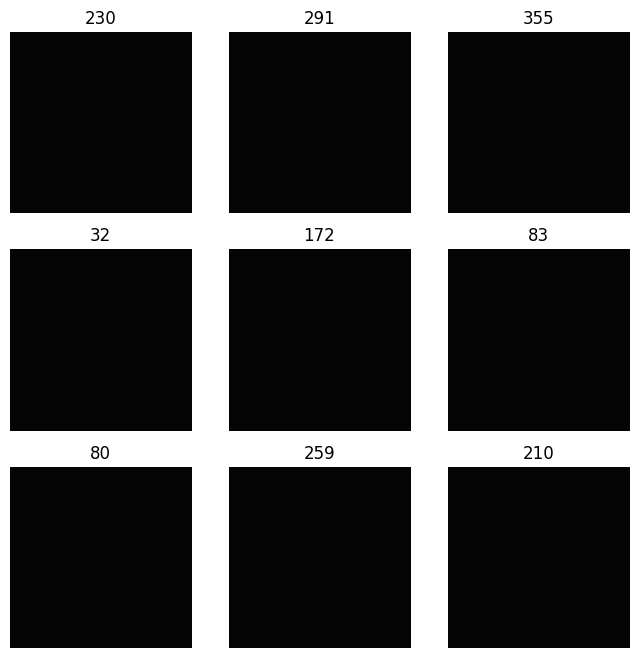

In [ ]:
for images,labels in train_ds.take(1):

    plt.figure(figsize=(8,8))

    for i in range(9):

        plt.subplot(
            3,
            3,
            i+1
        )

        plt.imshow(
            images[i]
        )

        plt.title(
            int(labels[i])
        )

        plt.axis("off")

    plt.show()

In [ ]:
print(
    tf.config.list_physical_devices()
)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
inputs = tf.keras.Input(
    shape=(112,112,3)
)

backbone = tf.keras.applications.MobileNetV3Small(

    include_top=False,

    weights="imagenet",

    input_shape=(112,112,3)

)

backbone.trainable = False

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


In [ ]:
x = backbone(inputs)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    512,
    activation="relu"
)(x)

x = tf.keras.layers.BatchNormalization()(x)

embedding = tf.keras.layers.Dense(
    256,
    activation=None,
    name="embedding"
)(x)

embedding_model = tf.keras.Model(
    inputs,
    embedding
)

In [ ]:
embedding_model.save(
    "/content/drive/MyDrive/face_embedding_model.keras"
)

In [ ]:
embeddings = []
labels = []

In [ ]:
def preprocess_image(path):

    img = cv2.imread(path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (112,112)
    )

    img = img.astype(
        np.float32
    ) / 255.0

    return img

In [ ]:
from tqdm import tqdm

BATCH_SIZE = 64

embeddings = []
labels = []

paths = train_df["image_path"].values
names = train_df["label"].values

for i in tqdm(
    range(
        0,
        len(paths),
        BATCH_SIZE
    )
):

    batch_paths = paths[
        i:i+BATCH_SIZE
    ]

    batch_labels = names[
        i:i+BATCH_SIZE
    ]

    batch_images = []

    for path in batch_paths:

        batch_images.append(
            preprocess_image(path)
        )

    batch_images = np.array(
        batch_images,
        dtype=np.float32
    )

    batch_embeddings = (
        embedding_model.predict(
            batch_images,
            verbose=0
        )
    )

    embeddings.extend(
        batch_embeddings
    )

    labels.extend(
        batch_labels
    )

100%|██████████| 58/58 [00:35<00:00,  1.65it/s]


In [ ]:
registration_df = train_df.groupby(
    "label",
    group_keys=False
).head(3)

In [ ]:
np.save(
    "/content/drive/MyDrive/embeddings.npy",
    np.array(embeddings)
)

np.save(
    "/content/drive/MyDrive/labels.npy",
    np.array(labels)
)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recognize_face(
    face_embedding,
    db_embeddings,
    db_labels,
    threshold=0.70
):

    sims = cosine_similarity(
        face_embedding.reshape(1,-1),
        db_embeddings
    )

    idx = np.argmax(sims)

    score = sims[0][idx]

    if score > threshold:

        return (
            db_labels[idx],
            score
        )

    return (
        "Unknown",
        score
    )

In [ ]:
np.save(
    "/content/drive/MyDrive/embeddings.npy",
    np.array(embeddings)
)

np.save(
    "/content/drive/MyDrive/labels.npy",
    np.array(labels)
)

print("Saved")

Saved


In [ ]:
db_embeddings = np.load(
    "/content/drive/MyDrive/embeddings.npy"
)

db_labels = np.load(
    "/content/drive/MyDrive/labels.npy",
    allow_pickle=True
)

print(db_embeddings.shape)
print(db_labels.shape)

(3708, 256)
(3708,)


In [ ]:
test_img = preprocess_image(
    train_df.iloc[0]["image_path"]
)

test_emb = embedding_model.predict(
    np.expand_dims(test_img,0),
    verbose=0
)[0]

name,score = recognize_face(

    test_emb,

    db_embeddings,

    db_labels,

    threshold=0.7

)

print(name)
print(score)

Yoko Ono
1.0


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(
    embedding_model
)

tflite_model = converter.convert()

with open(
    "/content/drive/MyDrive/face_embedding_model.tflite",
    "wb"
) as f:

    f.write(tflite_model)

Saved artifact at '/tmp/tmphwa4_ukx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 112, 112, 3), dtype=tf.float32, name='keras_tensor_185')
Output Type:
  TensorSpec(shape=(None, 256), dtype=tf.float32, name=None)
Captures:
  135034278884368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034278885904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034278887056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034278886288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034278886864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034278879184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034278881680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034278886480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034278886672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034278882448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13503427

In [ ]:
import os

print(
    os.path.exists(
        "/content/drive/MyDrive/face_embedding_model.tflite"
    )
)

True


In [ ]:
img = preprocess_image(
    train_df.iloc[0]["image_path"]
)

emb = embedding_model.predict(
    np.expand_dims(img,0),
    verbose=0
)

print(emb.shape)

(1, 256)


In [ ]:
test_img = preprocess_image(
    train_df.iloc[0]["image_path"]
)

test_emb = embedding_model.predict(
    np.expand_dims(test_img,0),
    verbose=0
)[0]

name, score = recognize_face(
    test_emb,
    db_embeddings,
    db_labels,
    threshold=0.70
)

print("Prediction:", name)
print("Similarity:", score)

Prediction: Yoko Ono
Similarity: 1.0
